In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fluid      import Fluid
from src.interpolator import LinearInterpolator
from src.reservoir  import ResProps, Reservoir
from src.pipe       import Pipe
from src.well       import Well
from src.compressor import DCS

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

In [2]:
M = 0.016
T_res = 310.0
df = pd.read_csv('hw2_data.csv', sep=';')
xa = df['xa, mol. %'].iloc[15]
xy = df['xy, mol. %'].iloc[15]
rho_c = df['rho_c, kg/m3'].iloc[15]

fluid = Fluid(M=M, rho_c=rho_c, xa=xa, xy=xy, T=T_res)

In [3]:
import math
roughness = 0.000046  # m

# Пласт (общий для всех трёх скважин)
P0    = 100.0   # atm
V_res = math.pi * 500**2 * 25   # m³

# NKT Скважины
nkt_1 = Pipe(L=2000, D=0.062, roughness=roughness, fluid=fluid, vertical_depth=1800)
nkt_2 = Pipe(L=2500, D=0.062, roughness=roughness, fluid=fluid, vertical_depth=1900)
nkt_3 = Pipe(L=1800, D=0.073, roughness=roughness, fluid=fluid, vertical_depth=1600)

# Скважины: [k, h, re, rw]
well_1 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_1)
well_2 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_2)
well_3 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_3)

# Шлейф
shlyf = Pipe(L=5000, D=0.200, roughness=roughness, fluid=fluid, vertical_depth=0)

# ДКС
CR     = 1.5
P_line = 5.0    # atm
q_ext  = 500.0  # ст.м³/сут
dcs   = DCS(CR=CR, P_line=P_line, q_ext=q_ext)

# Раздел 1 — Модель PVT

Графики Z(P), Bg(P), mu(P), ρ(P) в диапазоне 1–200 атм.

Сравнение ρ_ideal vs ρ_real

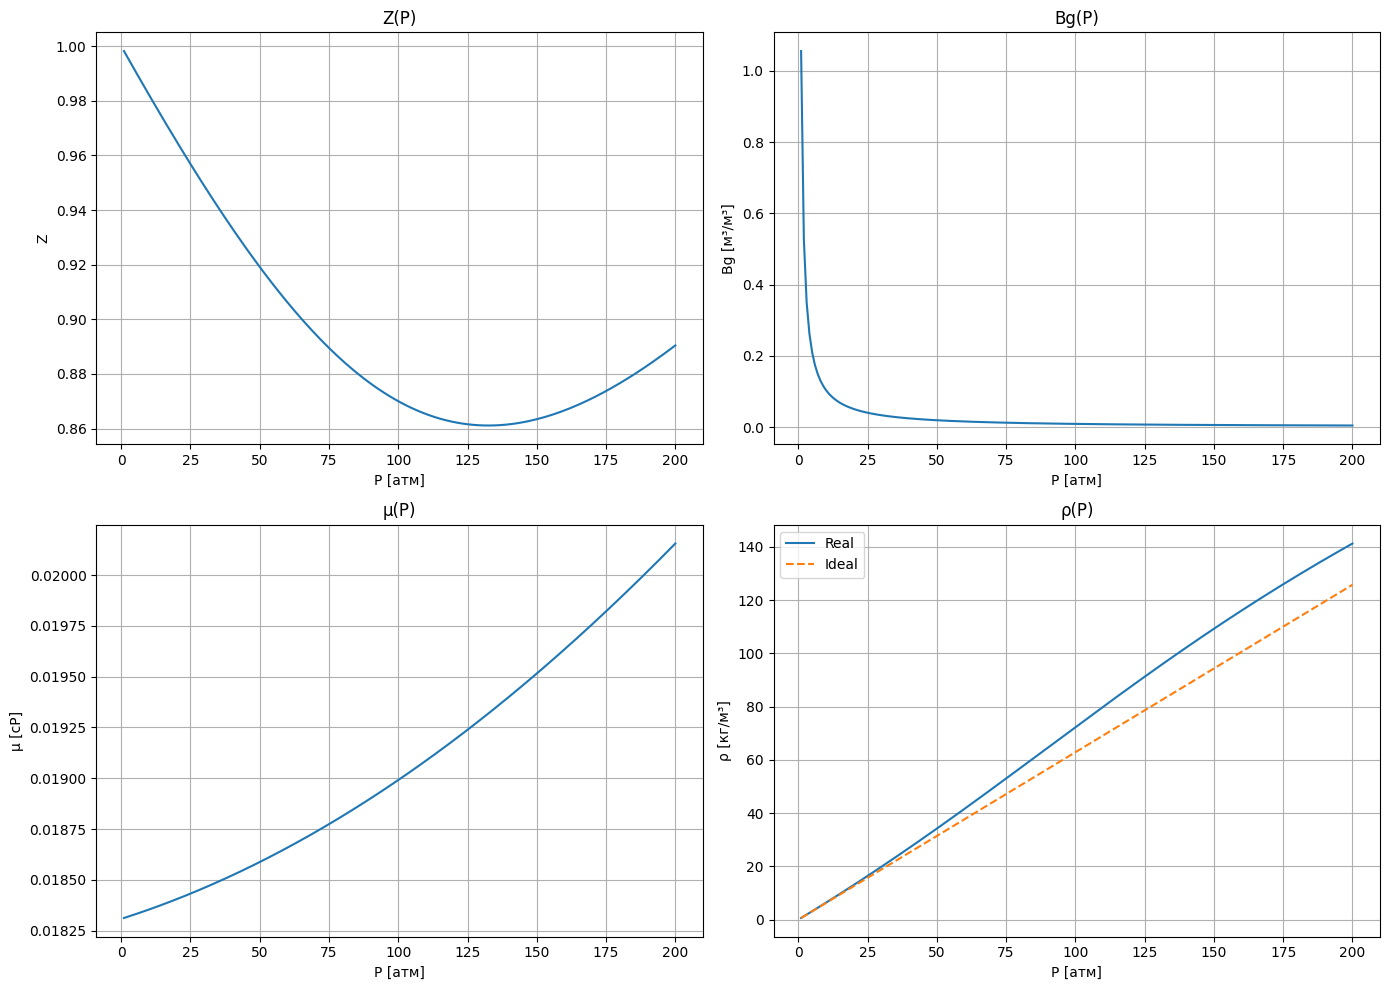

In [4]:
P_range = np.linspace(1, 200, 200)

Z_vals   = [fluid.z(P)   for P in P_range]
Bg_vals  = [fluid.bg(P)  for P in P_range]
mu_vals  = [fluid.mu(P)  for P in P_range]
rho_vals = [fluid.ro(P)  for P in P_range]

R = 8.314
rho_ideal = [P * 101325 * M / (1.0 * R * T_res) for P in P_range]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Графики Z(P), Bg(P), mu(P)
axes[0,0].plot(P_range, Z_vals);   axes[0,0].set(title='Z(P)', xlabel='P [атм]', ylabel='Z')
axes[0,1].plot(P_range, Bg_vals);  axes[0,1].set(title='Bg(P)', xlabel='P [атм]', ylabel='Bg [м³/м³]')
axes[1,0].plot(P_range, mu_vals);  axes[1,0].set(title='μ(P)', xlabel='P [атм]', ylabel='μ [cP]')
#ρ(P), cравнение ρ_ideal vs ρ_real
axes[1,1].plot(P_range, rho_vals, label='Real')
axes[1,1].plot(P_range, rho_ideal, '--', label='Ideal')
axes[1,1].set(title='ρ(P)', xlabel='P [атм]', ylabel='ρ [кг/м³]')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Раздел 2 — Модель пласта

кривая IPR при P_res = 100 атм для одной скважины.

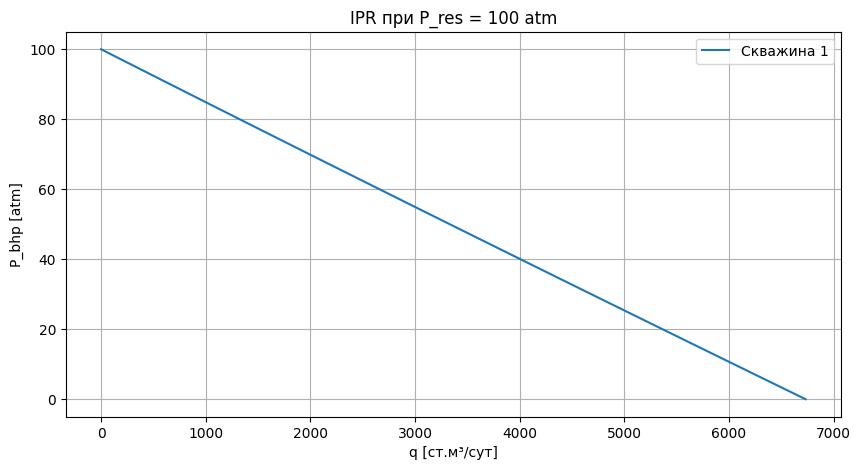

In [5]:
P_res = 100
P_bhp_range = np.linspace(0, P_res, 100)
q_ipr = [well_1.q(P_res, P_bhp) for P_bhp in P_bhp_range]

fig, ax = plt.subplots()
ax.plot(q_ipr, P_bhp_range, label=f'Скважина 1')
ax.set(xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]',
       title=f'IPR при P_res = {P_res} atm')
ax.legend()
plt.show()

# Раздел 3 — Гидравлика

кривые VLP трёх скважин и шлейфа. Зависимость λ(Re) по Колбруку–Уайту.

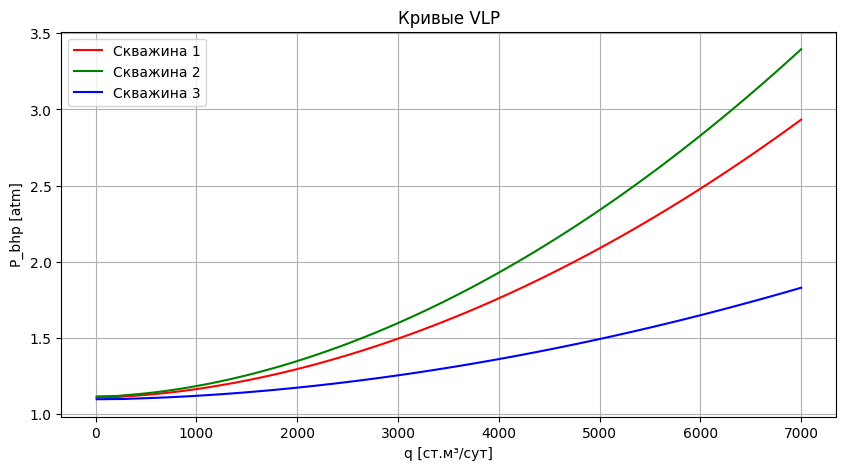

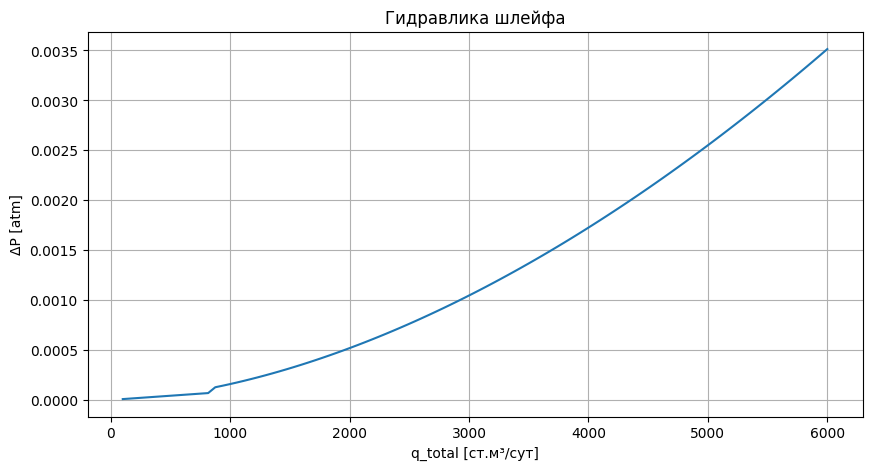

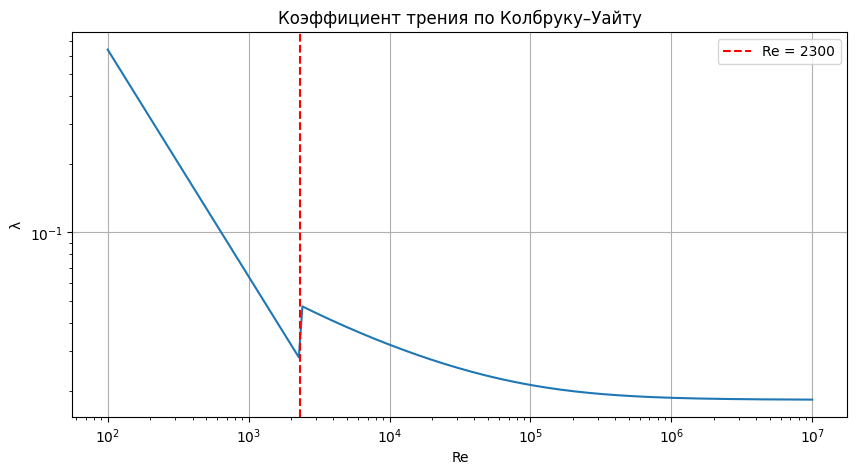

In [6]:
P_man = 1
q_range = np.linspace(10, 7000, 100)

vlp_1 = [P_man + nkt_1.dp(P_man, q).dP for q in q_range]
vlp_2 = [P_man + nkt_2.dp(P_man, q).dP for q in q_range]
vlp_3 = [P_man + nkt_3.dp(P_man, q).dP for q in q_range]

fig, ax = plt.subplots()
ax.plot(q_range, vlp_1, 'r-', label='Скважина 1')
ax.plot(q_range, vlp_2, 'g-', label='Скважина 2')
ax.plot(q_range, vlp_3, 'b-', label='Скважина 3')
ax.set(xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]', title='Кривые VLP')
plt.legend()
plt.show()

# VLP шлейфа
fig, ax = plt.subplots()
q_shlyf = np.linspace(100, 6000, 100)
dP_shlyf = [shlyf.dp(dcs.P_in(), q).dP for q in q_shlyf]

ax.plot(q_shlyf, dP_shlyf)
ax.set(xlabel='q_total [ст.м³/сут]', ylabel='ΔP [atm]', title='Гидравлика шлейфа')
plt.show()

# λ(Re)
Re_range = np.logspace(2, 7, 200)
lambda_vals = [nkt_1.f_lambda(Re) for Re in Re_range]

fig, ax = plt.subplots()
ax.loglog(Re_range, lambda_vals)
ax.axvline(2300, color='r', linestyle='--', label='Re = 2300')
ax.set(xlabel='Re', ylabel='λ', title='Коэффициент трения по Колбруку–Уайту')
ax.legend(); plt.show()



